Flagging Vendor Invoices for Manual Review
Objective: Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.
• Manual invoice review is time-consuming and does not scale with transaction volume.
• Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
• An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn= sqlite3.connect('C:/Users/nitin/Programming/Project/Untitled Folder 1/Data/inventory.db')

In [3]:
tables= pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'",conn)
for table in tables['name']:
    print(f'Table name: {table}')
    display(pd.read_sql(f"select* from {table} limit 5", conn))

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [4]:
tables= pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'",conn)
for table in tables['name']:
    print(f'Table name: {table}')
    display(pd.read_sql(f"select* from {table} limit 5", conn).dtypes)

Table name: purchases


InventoryId        object
Store               int64
Brand               int64
Description        object
Size               object
VendorNumber        int64
VendorName         object
PONumber            int64
PODate             object
ReceivingDate      object
InvoiceDate        object
PayDate            object
PurchasePrice     float64
Quantity            int64
Dollars           float64
Classification      int64
dtype: object

Table name: purchase_prices


Brand               int64
Description        object
Price             float64
Size               object
Volume             object
Classification      int64
PurchasePrice     float64
VendorNumber        int64
VendorName         object
dtype: object

Table name: vendor_invoice


VendorNumber      int64
VendorName       object
InvoiceDate      object
PONumber          int64
PODate           object
PayDate          object
Quantity          int64
Dollars         float64
Freight         float64
Approval         object
dtype: object

Table name: begin_inventory


InventoryId     object
Store            int64
City            object
Brand            int64
Description     object
Size            object
onHand           int64
Price          float64
startDate       object
dtype: object

Table name: end_inventory


InventoryId     object
Store            int64
City            object
Brand            int64
Description     object
Size            object
onHand           int64
Price          float64
endDate         object
dtype: object

In [5]:
purchase_agg_df= pd.read_sql_query("""
select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate)- julianday(p.PODate)) as avg_receiving_delay

from purchases p
group by p.PONumber
""",conn)

In [6]:
purchase_agg_df.shape

(5543, 5)

In [7]:
pd.read_sql_query("""
select
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate)- julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.payDate)- julianday(vi.InvoiceDate)) AS days_to_pay
from vendor_invoice vi
""",conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [8]:
df= pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber
""", conn)

In [9]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [10]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [11]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [12]:
def create_invoice_risk_label(row):
# Invoice total mismatch with item-level total 
    if (abs (row["invoice_dollars"]- row["total_item_dollars"])>5):
        return 1
        
# Abnormally high receiving delay
    if row["avg_receiving_delay"]> 10:
        return 1
    return 0
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1) 
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

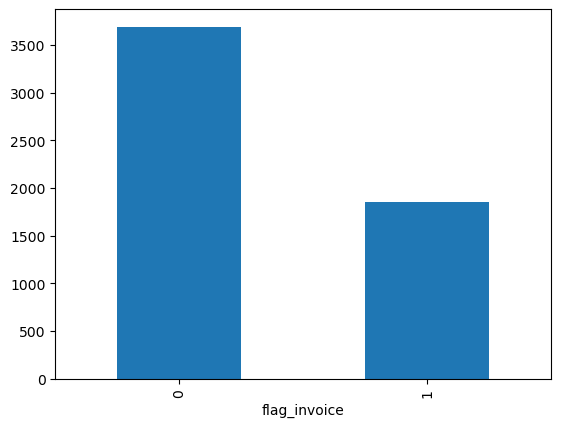

In [13]:
df['flag_invoice'].value_counts().plot(kind= 'bar')

In [14]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


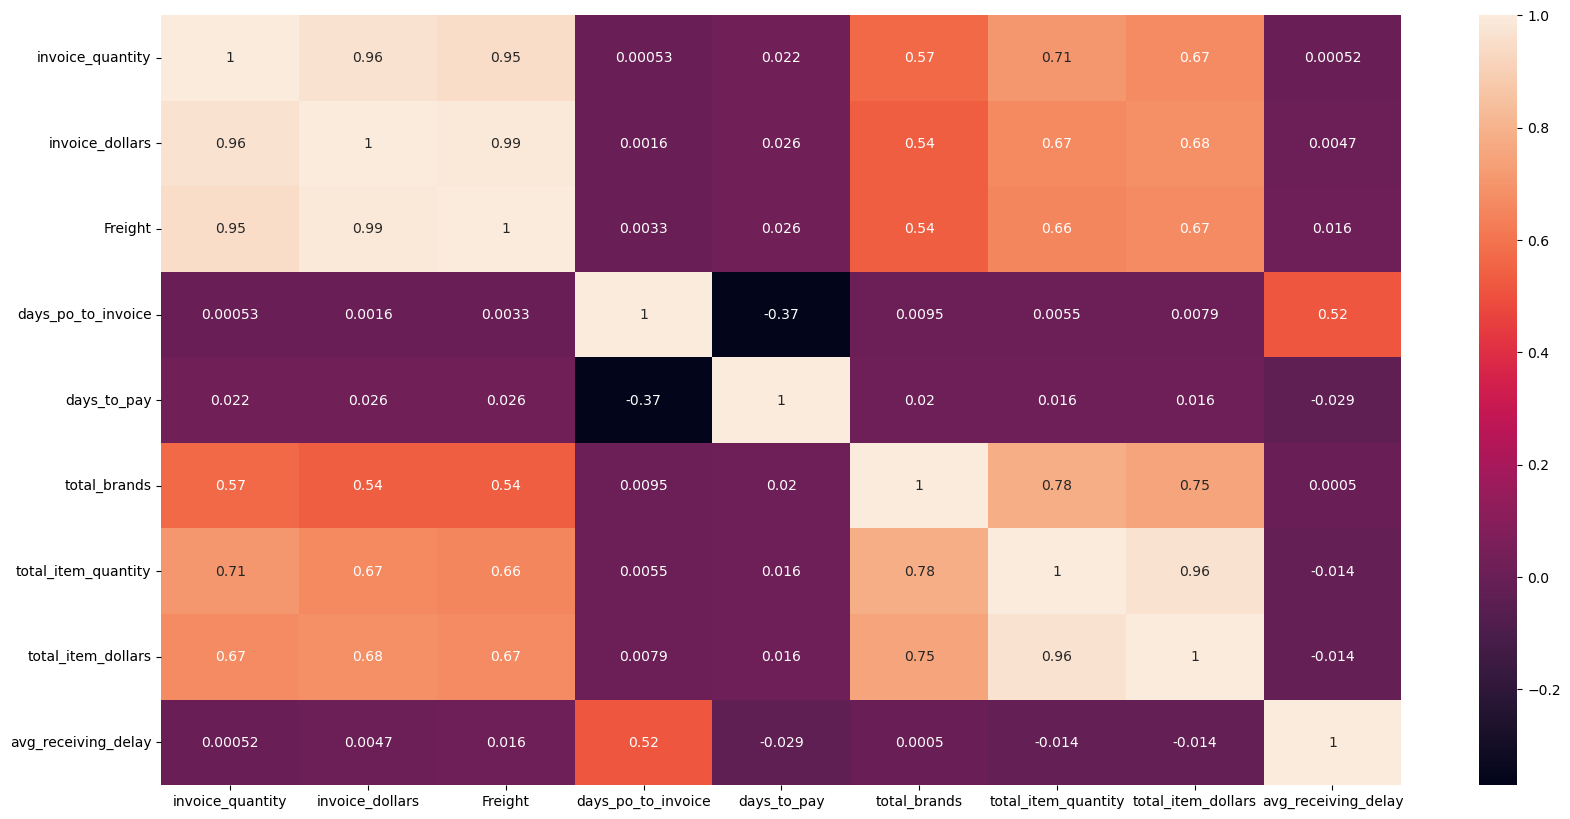

In [15]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:-1].corr(), annot=True)
plt.show()

In [16]:
flagged= df[df['flag_invoice']==1]
normal= df[df['flag_invoice']==0]

In [17]:
significant_features= []
non_significant_features= []
result= []

In [18]:
metrics=['invoice_quantity', 'invoice_dollars', 'Freight', 'dys_po_to_invoice', 'day_to_pay', 'total_brands',
         'total_item_quantity', 'total_item_dollrs', 'avg_receiving_delay']

In [19]:
# metrics = [
#     "days_po_to_invoice",
#     "days_to_pay",
#     "total_item_dollars",
#     "total_brands",
#     "total_item_quantity",
#     "avg_receiving_delay"
# ]

In [20]:
metrics = list(set(metrics))

In [22]:
# print("Checking:", metric)

In [23]:
# results = []
# significant_features = []
# non_significant_features = []

# metrics = list(set(metrics))

# for metric in metrics:
    
#     print("Checking:", metric)

#     if metric not in flagged.columns or metric not in normal.columns:
#         print(f"{metric} not found, skipping...")
#         continue

#     flagged_mean = flagged[metric].mean()
#     normal_mean = normal[metric].mean()

#     t_stat, p_value = ttest_ind(
#         flagged[metric].dropna(),
#         normal[metric].dropna(),
#         equal_var=False
#     )

#     if p_value < 0.05:
#         significant_features.append(metric)
#         results.append({
#             "metric": metric,
#             "flagged_mean": round(flagged_mean, 2),
#             "normal_mean": round(normal_mean, 2),
#             "p_value": round(p_value, 3)
#         })
#     else:
#         non_significant_features.append(metric)

In [24]:
non_significant_features

[]

In [25]:
print(flagged.columns)

Index(['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands',
       'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay',
       'flag_invoice'],
      dtype='object')


In [26]:
df.head()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000,1
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333,1
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000,0
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130,1
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809,0


In [27]:
from scipy.stats import ttest_ind

results = []
significant_features = []
non_significant_features = []

metrics = [
    "invoice_quantity",
    "invoice_dollars",
    "Freight",
    "days_po_to_invoice",
    "days_to_pay",
    "total_brands",
    "total_item_quantity",
    "total_item_dollars",
    "avg_receiving_delay"
]

for metric in metrics:

    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    result = {
        "metric": metric,
        "flagged_mean": round(flagged_mean, 2),
        "normal_mean": round(normal_mean, 2),
        "p_value": round(p_value, 3)
    }

    if p_value < 0.05:
        significant_features.append(metric)
        results.append(result)
    else:
        non_significant_features.append(metric)
        print(metric)
        print(result)

# Final Output
print("\nNon Significant Features:")
print(non_significant_features)

print("\nSignificant Features:")
print(significant_features)

days_to_pay
{'metric': 'days_to_pay', 'flagged_mean': np.float64(35.42), 'normal_mean': np.float64(35.49), 'p_value': np.float64(0.692)}
total_brands
{'metric': 'total_brands', 'flagged_mean': np.float64(42.29), 'normal_mean': np.float64(40.82), 'p_value': np.float64(0.508)}

Non Significant Features:
['days_to_pay', 'total_brands']

Significant Features:
['invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']


In [28]:
print(df.columns.tolist())

['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay', 'flag_invoice']


In [29]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [30]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

In [31]:
# Features (only significant ones use karo)
x = df[[
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'days_po_to_invoice',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
]]

# Target
y = df['flag_invoice']

In [32]:
x.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0,13.0


In [33]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [36]:
model1= LogisticRegression(random_state=42)
model1.fit(x_train_scaled, y_train)

model2= DecisionTreeClassifier(random_state= 42)
model2.fit(x_train_scaled, y_train)

model3= RandomForestClassifier(random_state= 42)
model3.fit(x_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
import os
print(os.getcwd())

C:\Users\nitin\Programming\Project\Untitled Folder 1\Notebook


In [40]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))

In [41]:
evaluate_model(model1, x_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, x_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, x_test_scaled, y_test, 'Random Forest Classifier')


Logistic Regression
Accuracy: 0.739404869251578
              precision    recall  f1-score   support

           0       0.74      0.93      0.82       725
           1       0.74      0.38      0.50       384

    accuracy                           0.74      1109
   macro avg       0.74      0.66      0.66      1109
weighted avg       0.74      0.74      0.71      1109


Decision Tree Classifier
Accuracy: 0.9486023444544635
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       725
           1       0.95      0.90      0.92       384

    accuracy                           0.95      1109
   macro avg       0.95      0.94      0.94      1109
weighted avg       0.95      0.95      0.95      1109


Random Forest Classifier
Accuracy: 0.9558160504959423
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       725
           1       1.00      0.87      0.93       384

    accuracy           

In [43]:
model3.feature_importances_

array([0.10668727, 0.10055568, 0.10323929, 0.02603186, 0.15331893,
       0.20578767, 0.3043793 ])

In [45]:
feature_importance = pd.DataFrame({
    "feature": x_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
6,avg_receiving_delay,0.304379
5,total_item_dollars,0.205788
4,total_item_quantity,0.153319
0,invoice_quantity,0.106687
2,Freight,0.103239
1,invoice_dollars,0.100556
3,days_po_to_invoice,0.026032


In [47]:
# Features (only significant ones use karo)
x = df[[
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
]]

# Target
y = df['flag_invoice']

In [49]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

model3= RandomForestClassifier(random_state= 42)
model3.fit(x_train_scaled, y_train)

evaluate_model(model3, x_test_scaled, y_test, 'Random Forest Classifier')


Random Forest Classifier
Accuracy: 0.9666366095581606
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       725
           1       1.00      0.90      0.95       384

    accuracy                           0.97      1109
   macro avg       0.98      0.95      0.96      1109
weighted avg       0.97      0.97      0.97      1109



In [51]:
param_grid = {
    "n_estimators": [100,200, 300], 
    "max_depth": [None, 4, 5, 6], 
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5], 
    "criterion": ['gini', 'entropy']
}

In [56]:
from sklearn.metrics import make_scorer, f1_score 
from sklearn.model_selection import GridSearchCV 
rf= RandomForestClassifier(
    random_state=42, 
    n_jobs=-1
)
param_grid = {
    "n_estimators": [100,200, 300], 
    "max_depth": [None, 4, 5, 6], 
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5], 
    "criterion": ['gini', 'entropy']
}
scorer = make_scorer(f1_score) 
grid_search= GridSearchCV(
    estimator=rf,
    param_grid=param_grid, 
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)
grid_search.fit(x_train_scaled, y_train)
evaluate_model(grid_search, x_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier
Accuracy: 0.9666366095581606
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       725
           1       1.00      0.90      0.95       384

    accuracy                           0.97      1109
   macro avg       0.98      0.95      0.96      1109
weighted avg       0.97      0.97      0.97      1109



In [57]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(grid_search.predict(x_test_scaled), y_test)

In [ ]:
confusion_matrix(model3.predict(x_test_scaled), y_test)

In [ ]:
grid_search.best_params_